## Imports og tilkobling

In [154]:
import sys
import os
sys.path.append('../../../src')
import feature_engineering.værdata as vd
from dotenv import load_dotenv
from azure.storage.blob import BlobServiceClient

load_dotenv()

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")

blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_name = "processeddata"

## Finn og velg værstasjon

In [155]:
# Frikstad koordinater
frikstad_coords = (58.13969, 8.11882)

# Velg stasjon
station_1, _ = vd.finn_naermeste_stasjon(*frikstad_coords, stasjon_index=1)
station_4, _ = vd.finn_naermeste_stasjon(*frikstad_coords, stasjon_index=4)

print("Temp fra:", station_1)
print("Vind fra:", station_4)

Temp fra: SN39150
Vind fra: SN39040


## Definer periode

In [156]:
vinter_periods = [
    ("2024-11-03T23:00:00Z", "2024-11-30T23:00:00Z"),
    ("2024-12-01T00:00:00Z", "2024-12-31T23:00:00Z"),
    ("2025-01-01T00:00:00Z", "2025-01-31T23:00:00Z"),
    ("2025-11-01T00:00:00Z", "2025-11-30T23:00:00Z"),
    ("2025-12-01T00:00:00Z", "2025-12-31T23:00:00Z"),
    ("2026-01-01T00:00:00Z", "2026-01-17T22:00:00Z")
]

## Hent time for time værdata

In [157]:
# Hent data
df_station_1 = vd.fetch_weather_periods_hourly(station_1, vinter_periods)
df_station_4 = vd.fetch_weather_periods_hourly(station_4, vinter_periods)

# Velg riktige kolonner
df_station_1 = df_station_1[["timestamp", "air_temperature"]]
df_station_4 = df_station_4[["timestamp", "wind_speed", "precipitation_mm"]]

In [158]:
# Merge
weather_df_hourly = df_station_1.merge(df_station_4, on="timestamp", how="left")

weather_df_hourly = weather_df_hourly[
    ["timestamp", "air_temperature", "wind_speed", "precipitation_mm"]
]

weather_df_hourly.head()

,timestamp,air_temperature,wind_speed,precipitation_mm
0,2024-11-03 23:00:00,8.8,1.9,0.0
1,2024-11-04 00:00:00,8.1,3.0,0.0
2,2024-11-04 01:00:00,8.0,3.0,0.0
3,2024-11-04 02:00:00,8.0,3.0,0.0
4,2024-11-04 03:00:00,8.1,1.9,0.0


## Last opp til Azure Blob

In [159]:
import io

# --- Lag CSV i minnet ---
csv_buffer = io.BytesIO()
weather_df_hourly.to_csv(csv_buffer, index=False)
csv_buffer.seek(0)  # gå til starten av bufferet

# --- Last opp til blob ---
output_blob_name = "FRIKSTAD_weather.csv"
blob_client = blob_service_client.get_blob_client(container=container_name, blob=output_blob_name)
blob_client.upload_blob(csv_buffer, overwrite=True)  # overwrite=True overskriver eksisterende fil

print(f"{output_blob_name} lastet opp til blob!")

FRIKSTAD_weather.csv lastet opp til blob!


# Kvalitetssikring

## Sjekk struktur

In [136]:
print(weather_df_hourly.info())
print(weather_df_hourly.head())

<class 'pandas.DataFrame'>
RangeIndex: 4002 entries, 0 to 4001
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         4002 non-null   str    
 1   air_temperature   4002 non-null   float64
 2   wind_speed        4002 non-null   float64
 3   precipitation_mm  4002 non-null   float64
dtypes: float64(3), str(1)
memory usage: 125.2 KB
None
             timestamp  air_temperature  wind_speed  precipitation_mm
0  2024-11-03 23:00:00              8.8         1.9               0.0
1  2024-11-04 00:00:00              8.1         3.0               0.0
2  2024-11-04 01:00:00              8.0         3.0               0.0
3  2024-11-04 02:00:00              8.0         3.0               0.0
4  2024-11-04 03:00:00              8.1         1.9               0.0


## Sjekk tidsserien

In [137]:
weather_df_hourly = weather_df_hourly.sort_values("timestamp")

In [138]:
import pandas as pd

def check_missing_per_period(df, periods):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_localize(None)
    
    for start, end in periods:
        start = pd.to_datetime(start).tz_localize(None)
        end = pd.to_datetime(end).tz_localize(None)

        # Lag alle forventede timer
        expected = pd.date_range(start=start, end=end, freq="h")
        
        # Faktiske timer i datasettet
        actual = df[
            (df["timestamp"] >= start) & 
            (df["timestamp"] <= end)
        ]["timestamp"]
        
        # Finn hvilke timer som mangler
        missing = expected.difference(actual)
        
        print(f"\nPeriode: {start} → {end}")
        print("Antall manglende timer:", len(missing))
        print("Manglende timer:")
        print(missing)  # viser alle timestampene som mangler

In [139]:
check_missing_per_period(weather_df_hourly, vinter_periods)


Periode: 2024-11-03 23:00:00 → 2024-11-30 23:00:00
Antall manglende timer: 1
Manglende timer:
DatetimeIndex(['2024-11-30 23:00:00'], dtype='datetime64[us]', freq='h')

Periode: 2024-12-01 00:00:00 → 2024-12-31 23:00:00
Antall manglende timer: 1
Manglende timer:
DatetimeIndex(['2024-12-31 23:00:00'], dtype='datetime64[us]', freq='h')

Periode: 2025-01-01 00:00:00 → 2025-01-31 23:00:00
Antall manglende timer: 1
Manglende timer:
DatetimeIndex(['2025-01-31 23:00:00'], dtype='datetime64[us]', freq='h')

Periode: 2025-11-01 00:00:00 → 2025-11-30 23:00:00
Antall manglende timer: 1
Manglende timer:
DatetimeIndex(['2025-11-30 23:00:00'], dtype='datetime64[us]', freq='h')

Periode: 2025-12-01 00:00:00 → 2025-12-31 23:00:00
Antall manglende timer: 1
Manglende timer:
DatetimeIndex(['2025-12-31 23:00:00'], dtype='datetime64[us]', freq='h')

Periode: 2026-01-01 00:00:00 → 2026-01-17 22:00:00
Antall manglende timer: 1
Manglende timer:
DatetimeIndex(['2026-01-17 22:00:00'], dtype='datetime64[us]', fr

## Sjekk verdier

In [140]:
# Temperatur
weather_df_hourly["air_temperature"].describe()

count    4002.000000
mean        4.111944
std         4.723516
min       -10.500000
25%         0.700000
50%         4.900000
75%         7.900000
max        14.300000
Name: air_temperature, dtype: float64

In [141]:
# Sjekk for ekstreme temperaturer
weather_df_hourly[
    (weather_df_hourly["air_temperature"] < -40) |
    (weather_df_hourly["air_temperature"] > 40)
]

,timestamp,air_temperature,wind_speed,precipitation_mm


In [142]:
# Vind
weather_df_hourly["wind_speed"].describe()

count    4002.000000
mean        3.728311
std         2.410144
min         0.000000
25%         1.900000
50%         3.200000
75%         5.100000
max        15.900000
Name: wind_speed, dtype: float64

In [143]:
# Sjekk for ekstreme vindhastigheter
weather_df_hourly[
    weather_df_hourly["wind_speed"] > 40
]

,timestamp,air_temperature,wind_speed,precipitation_mm


In [144]:
# Nedbør
weather_df_hourly["precipitation_mm"].describe()

count    4002.000000
mean        0.219540
std         0.696431
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.100000
Name: precipitation_mm, dtype: float64

In [145]:
# Sjekk for ekstrem nedbør
print("Max:", weather_df_hourly["precipitation_mm"].max())

# Sjekk hvor mange timer det er nedbør
print("Non-zero:", (weather_df_hourly["precipitation_mm"] > 0).sum())

Max: 9.1
Non-zero: 850


## Manglende verdier

In [146]:
weather_df_hourly.isna().sum()

timestamp           0
air_temperature     0
wind_speed          0
precipitation_mm    0
dtype: int64

In [147]:
weather_df_hourly['precipitation_mm'].value_counts(dropna=False)

precipitation_mm
0.0    3152
0.1     158
0.2      93
0.3      62
0.4      56
0.6      48
0.5      39
0.7      36
0.8      32
0.9      30
1.4      23
1.2      22
1.1      18
1.0      18
1.6      16
1.7      14
2.3      13
1.3      12
1.5      12
1.9      12
2.0      11
2.7      10
2.6       8
2.9       8
2.2       7
4.3       6
2.5       6
1.8       6
2.1       6
3.2       6
2.4       5
3.8       5
4.4       5
3.1       4
2.8       4
3.0       4
4.7       4
3.6       3
4.0       3
3.9       3
4.1       3
4.6       2
3.5       2
5.4       2
4.2       2
4.8       2
3.7       1
9.1       1
7.4       1
8.7       1
5.5       1
6.0       1
3.4       1
5.7       1
4.5       1
Name: count, dtype: int64

## Merge kvalitet

In [148]:
print("Rows before merge:", len(df_station_1))
print("Rows after merge:", len(weather_df_hourly))

Rows before merge: 4002
Rows after merge: 4002


In [149]:
weather_df_hourly["wind_speed"].isna().sum()

np.int64(0)

## Korrelasjon sanity check

In [150]:
weather_df_hourly.corr(numeric_only=True)

,air_temperature,wind_speed,precipitation_mm
air_temperature,1.000000,0.226968,0.161654
wind_speed,0.226968,1.000000,0.276537
precipitation_mm,0.161654,0.276537,1.000000


## Kvalitetsscore

In [151]:
def quality_report(df):
    print("---- QUALITY REPORT ----")
    print("Rows:", len(df))
    print("\nMissing values:")
    print(df.isna().sum())
    
    print("\nNon-zero precipitation:", (df["precipitation_mm"] > 0).sum())
    print("Max precipitation:", df["precipitation_mm"].max())
    
    print("\nTemperature range:",
          df["air_temperature"].min(),
          "to",
          df["air_temperature"].max())
    
    print("\nWind max:", df["wind_speed"].max())

quality_report(weather_df_hourly)

---- QUALITY REPORT ----
Rows: 4002

Missing values:
timestamp           0
air_temperature     0
wind_speed          0
precipitation_mm    0
dtype: int64

Non-zero precipitation: 850
Max precipitation: 9.1

Temperature range: -10.5 to 14.3

Wind max: 15.9


# Graf

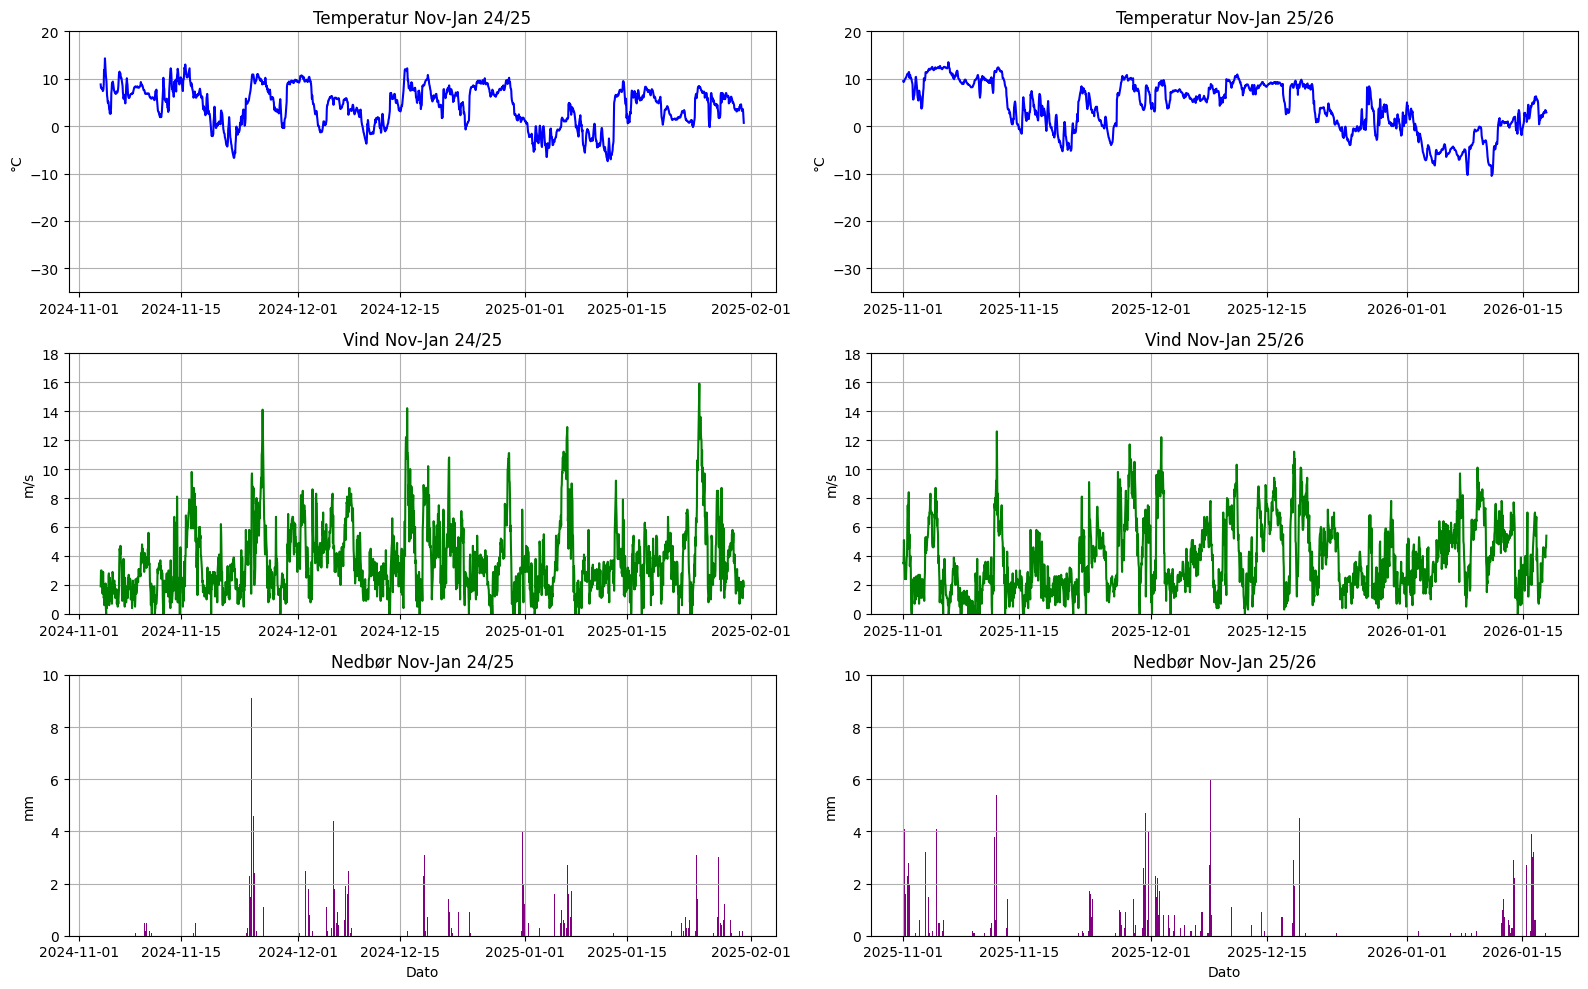

In [152]:
import pandas as pd
import matplotlib.pyplot as plt

# Anta df har kolonnene: timestamp, air_temperature, wind_speed, precipitation_mm
weather_df_hourly['timestamp'] = pd.to_datetime(weather_df_hourly['timestamp']).dt.tz_localize(None)

# Definer periodene
periods = {
    'Nov-Jan 24/25': ('2024-11-01', '2025-01-31'),
    'Nov-Jan 25/26': ('2025-11-01', '2026-01-31')
}

# Lag subplot: 3 rader (temperatur, vind, nedbør), 2 kolonner (perioder)
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharey=False)

for col_idx, (periode, (start, end)) in enumerate(periods.items()):
    mask = (weather_df_hourly['timestamp'] >= pd.to_datetime(start)) & (weather_df_hourly['timestamp'] <= pd.to_datetime(end))
    temp_df = weather_df_hourly[mask]

    # Temperatur
    axes[0, col_idx].plot(temp_df['timestamp'], temp_df['air_temperature'], color='blue')
    axes[0, col_idx].set_title(f'Temperatur {periode}')
    axes[0, col_idx].set_ylim(-35, 20)  # fast y-akse
    axes[0, col_idx].set_ylabel('°C')
    axes[0, col_idx].grid(True)

    # Vind
    axes[1, col_idx].plot(temp_df['timestamp'], temp_df['wind_speed'], color='green')
    axes[1, col_idx].set_title(f'Vind {periode}')
    axes[1, col_idx].set_ylim(0, 18)
    axes[1, col_idx].set_ylabel('m/s')
    axes[1, col_idx].grid(True)

    # Nedbør
    axes[2, col_idx].bar(temp_df['timestamp'], temp_df['precipitation_mm'], color='purple', width=0.03)
    axes[2, col_idx].set_title(f'Nedbør {periode}')
    axes[2, col_idx].set_ylim(0, 10)  # maks nedbør for sammenligning
    axes[2, col_idx].set_ylabel('mm')
    axes[2, col_idx].grid(True)

# Felles x-akse format
for ax in axes[2, :]:
    ax.set_xlabel('Dato')

plt.tight_layout()
plt.show()